In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.manifold import MDS


In [ ]:

# --- CONFIGURATION ---
DATA_ROOT = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/DATA_NPZ")
RESULTS_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/ECOC_Results")
PLOTS_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots")

for d in [RESULTS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PATHWAYS = ["Luminance_NPZ", "L_M_NPZ", "S_cone_NPZ"]
LABELS = ["5%", "10%", "50%", "100%"]
N_FOLDS = 5
DECODER = make_pipeline(StandardScaler(), OneVsRestClassifier(LinearDiscriminantAnalysis()))

In [9]:
def run_power_decoding(pathway_folder):
    pathway_name = pathway_folder.replace("_NPZ", "")
    input_path = DATA_ROOT / pathway_folder
    files = sorted(list(input_path.glob("*.npz")))
    
    print(f"Starting Power Decoding: {pathway_name} | {len(files)} subjects")
    summary_data = []

    for i, f in enumerate(files):
        sub_id = f.name.split("_")[0]
        data = np.load(f, allow_pickle=True)
        X, y, times = data['X'], data['y'], data['times']
        
        unique_y = np.unique(y)
        n_classes = len(unique_y)
        scores = np.zeros(X.shape[2])
        cms = np.zeros((X.shape[2], n_classes, n_classes))
        
        cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        
        for t in range(X.shape[2]):
            X_t = X[:, :, t]
            fold_acc = []
            for train_idx, test_idx in cv.split(X_t, y):
                DECODER.fit(X_t[train_idx], y[train_idx])
                y_pred = DECODER.predict(X_t[test_idx])
                fold_acc.append(DECODER.score(X_t[test_idx], y[test_idx]))
                cms[t] += confusion_matrix(y[test_idx], y_pred, labels=unique_y)
            
            scores[t] = np.mean(fold_acc)
            cms[t] = cms[t] / cms[t].sum(axis=1)[:, None]
        
        peak_idx = np.argmax(scores)
        summary_data.append({"subject": sub_id, "pathway": pathway_name, 
                             "best_time": times[peak_idx], "peak_score": scores[peak_idx]})
        
        joblib.dump({"times": times, "scores": scores, "cms": cms, "contrasts": unique_y}, 
                    RESULTS_DIR / f"{sub_id}_{pathway_name}_decoding.joblib")
        
        if (i + 1) % 5 == 0 or (i + 1) == len(files):
            print(f"  Progress: {i+1}/{len(files)} completed")
    return pd.DataFrame(summary_data)

# Execution
all_results = [run_power_decoding(p) for p in PATHWAYS]
pd.concat(all_results).to_csv(RESULTS_DIR / "Master_Decoding_Summary.csv", index=False)

Starting Power Decoding: Luminance | 49 subjects
  Progress: 5/49 completed
  Progress: 10/49 completed
  Progress: 15/49 completed
  Progress: 20/49 completed
  Progress: 25/49 completed
  Progress: 30/49 completed
  Progress: 35/49 completed
  Progress: 40/49 completed
  Progress: 45/49 completed
  Progress: 49/49 completed
Starting Power Decoding: L_M | 49 subjects
  Progress: 5/49 completed
  Progress: 10/49 completed
  Progress: 15/49 completed
  Progress: 20/49 completed
  Progress: 25/49 completed
  Progress: 30/49 completed
  Progress: 35/49 completed
  Progress: 40/49 completed
  Progress: 45/49 completed
  Progress: 49/49 completed
Starting Power Decoding: S_cone | 49 subjects
  Progress: 5/49 completed
  Progress: 10/49 completed
  Progress: 15/49 completed
  Progress: 20/49 completed
  Progress: 25/49 completed
  Progress: 30/49 completed
  Progress: 35/49 completed
  Progress: 40/49 completed
  Progress: 45/49 completed
  Progress: 49/49 completed


In [14]:
# Define pathways and colors to match your report
PATHWAYS = ["Luminance", "L_M", "S_cone"]
COLORS = {"Luminance": "#F00C0C", "L_M": "#2ca02c", "S_cone": "#1f77b4"}

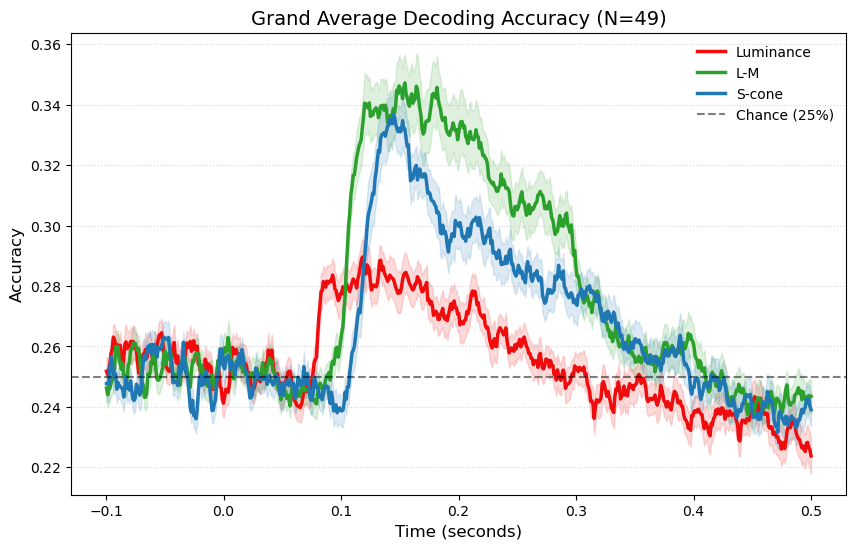

Success: Grand Average plot saved to /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots/01_Grand_Average_Timecourse.png


In [15]:
def plot_grand_average(results_dir, plots_dir):
    plt.figure(figsize=(10, 6))
    
    for p in PATHWAYS:
        # Find all files for the specific pathway
        files = list(results_dir.glob(f"*{p}*.joblib"))
        if not files:
            continue
            
        # Load all scores for this pathway
        all_scores = [joblib.load(f)['scores'] for f in files]
        times = joblib.load(files[0])['times']
        
        # Calculate Mean and SEM
        avg_score = np.mean(all_scores, axis=0)
        sem_score = np.std(all_scores, axis=0) / np.sqrt(len(files))
        
        # Plotting
        plt.plot(times, avg_score, label=p.replace('_', '-'), color=COLORS[p], linewidth=2.5)
        plt.fill_between(times, avg_score - sem_score, avg_score + sem_score, color=COLORS[p], alpha=0.15)

    # Add chance level and formatting
    plt.axhline(0.25, color='black', linestyle='--', alpha=0.5, label='Chance (25%)')
    plt.title("Grand Average Decoding Accuracy (N=49)", fontsize=14)
    plt.xlabel("Time (seconds)", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.legend(frameon=False)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    
    # Save the plot
    save_path = plots_dir / "01_Grand_Average_Timecourse.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Success: Grand Average plot saved to {save_path}")

# Run this block
plot_grand_average(RESULTS_DIR, PLOTS_DIR)

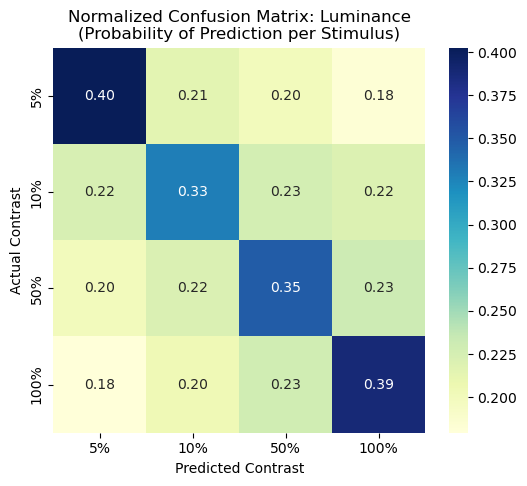

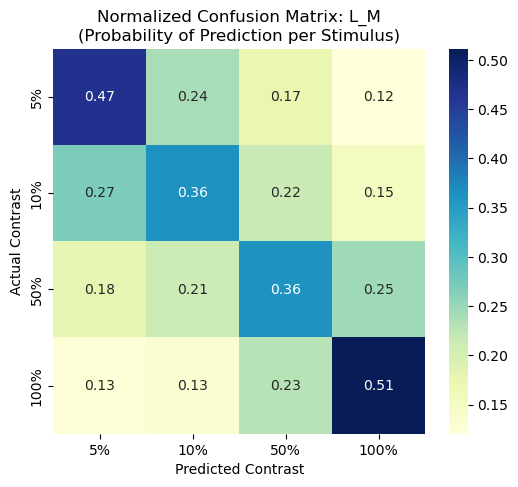

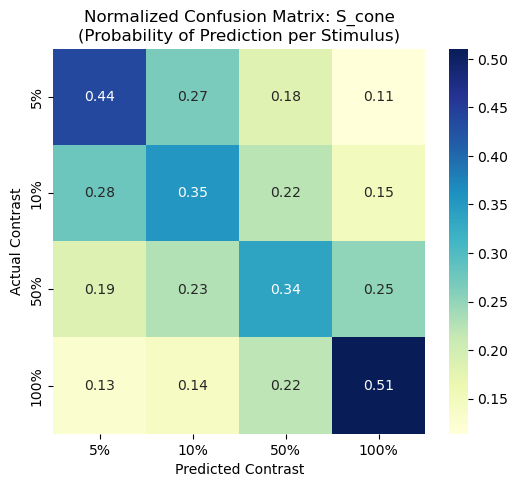

In [20]:
def plot_orderly_heatmaps(results_dir, plots_dir):
    for p in ["Luminance", "L_M", "S_cone"]:
        files = list(results_dir.glob(f"*{p}*.joblib"))
        if not files: continue
            
        all_cms_normalized = []
        for f in files:
            data = joblib.load(f)
            # Find the index of maximum accuracy
            peak_idx = np.argmax(data['scores'])
            cm = data['cms'][peak_idx]
            
            # Row-normalize: Divide each row by its sum 
            # (Makes each cell represent % of total guesses for that contrast)
            row_sums = cm.sum(axis=1, keepdims=True)
            # Avoid division by zero
            row_sums[row_sums == 0] = 1
            cm_norm = cm / row_sums
            all_cms_normalized.append(cm_norm)
        
        avg_cm_norm = np.mean(all_cms_normalized, axis=0)
        
        plt.figure(figsize=(6, 5))
        sns.heatmap(avg_cm_norm, annot=True, fmt=".2f", cmap="YlGnBu", 
                    xticklabels=LABELS, yticklabels=LABELS)
        plt.title(f"Normalized Confusion Matrix: {p}\n(Probability of Prediction per Stimulus)")
        plt.xlabel("Predicted Contrast")
        plt.ylabel("Actual Contrast")
        plt.show()

plot_orderly_heatmaps(RESULTS_DIR, PLOTS_DIR)

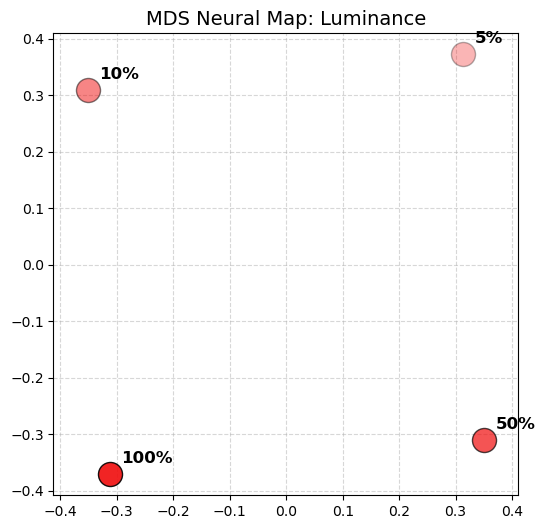

Saved: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots/03_MDS_Luminance.png


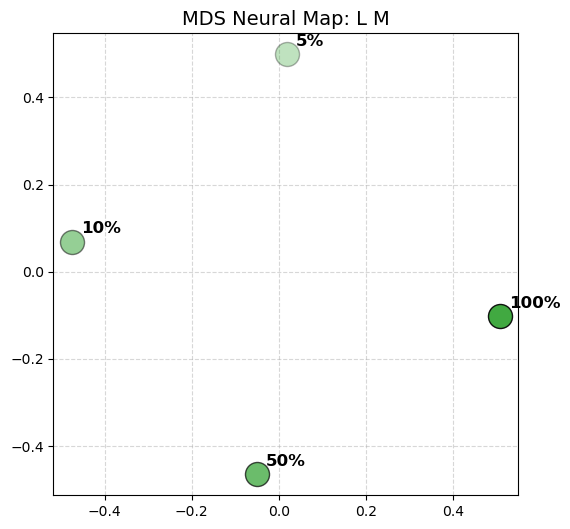

Saved: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots/03_MDS_L_M.png


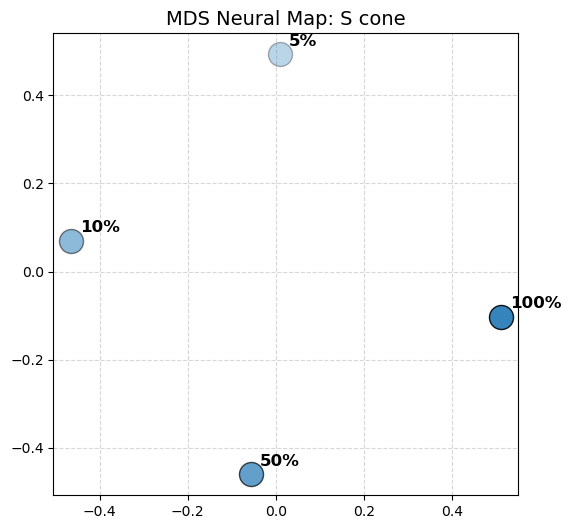

Saved: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots/03_MDS_S_cone.png


In [18]:
def plot_mds_maps(results_dir, plots_dir):
    for p in PATHWAYS:
        files = list(results_dir.glob(f"*{p}*.joblib"))
        if not files:
            continue
            
        # 1. Collect CMs at peak time for all subjects
        all_cms_at_peak = []
        for f in files:
            data = joblib.load(f)
            peak_t_idx = np.argmax(data['scores'])
            all_cms_at_peak.append(data['cms'][peak_t_idx])
        
        # 2. Average and Symmetrize
        avg_cm = np.mean(all_cms_at_peak, axis=0)
        avg_cm_sym = (avg_cm + avg_cm.T) / 2.0
        
        # 3. Convert to Distance Matrix (Dissimilarity)
        dist_matrix = 1 - avg_cm_sym
        np.fill_diagonal(dist_matrix, 0) # Distance to self is 0
        
        # 4. Run MDS
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
        pos = mds.fit_transform(dist_matrix)
        
        # 5. Plotting
        plt.figure(figsize=(6, 6))
        # Use a gradient of your pathway color (light to dark)
        base_color = COLORS[p]
        
        for j, label in enumerate(LABELS):
            plt.scatter(pos[j, 0], pos[j, 1], s=300, color=base_color, 
                        edgecolors='k', alpha=0.3 + (j*0.2), zorder=3)
            plt.text(pos[j, 0] + 0.02, pos[j, 1] + 0.02, label, 
                     fontsize=12, fontweight='bold')
        
        plt.title(f"MDS Neural Map: {p.replace('_', ' ')}", fontsize=14)
        plt.axis('equal')
        plt.grid(True, linestyle='--', alpha=0.5)
        
        # Save
        save_path = plots_dir / f"03_MDS_{p}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {save_path}")

# Run this block
plot_mds_maps(RESULTS_DIR, PLOTS_DIR)

In [19]:
def export_distances_for_modeling(results_dir):
    all_distance_data = []

    for p in PATHWAYS:
        files = list(results_dir.glob(f"*{p}*.joblib"))
        if not files:
            continue
            
        print(f"Exporting distances for: {p}")
            
        for f in files:
            data = joblib.load(f)
            sub_id = f.name.split('_')[0]
            
            # Find peak decoding time for this subject
            peak_t_idx = np.argmax(data['scores'])
            cm_at_peak = data['cms'][peak_t_idx]
            
            # Symmetrize and create distance matrix
            cm_sym = (cm_at_peak + cm_at_peak.T) / 2.0
            dist_matrix = 1 - cm_sym
            np.fill_diagonal(dist_matrix, 0)
            
            # Run MDS to get 2D coordinates
            mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
            pos = mds.fit_transform(dist_matrix)
            
            # Calculate Euclidean distance of each point from the 5% baseline
            # Distance = sqrt((x_i - x_5)^2 + (y_i - y_5)^2)
            base_point = pos[0] # The 5% contrast point
            distances = [np.linalg.norm(pos[i] - base_point) for i in range(len(pos))]
            
            all_distance_data.append({
                "subject": sub_id,
                "pathway": p,
                "dist_5": distances[0],   # Should be 0.0
                "dist_10": distances[1],
                "dist_50": distances[2],
                "dist_100": distances[3],
                "peak_latency": data['times'][peak_t_idx],
                "peak_accuracy": data['scores'][peak_t_idx]
            })
    
    # Save to CSV
    output_df = pd.DataFrame(all_distance_data)
    save_path = results_dir / "Neural_Distances_for_Modeling.csv"
    output_df.to_csv(save_path, index=False)
    print(f"\n✅ SUCCESS: File 1 complete. Data saved to: {save_path}")

# Run the export
export_distances_for_modeling(RESULTS_DIR)

Exporting distances for: Luminance
Exporting distances for: L_M
Exporting distances for: S_cone

✅ SUCCESS: File 1 complete. Data saved to: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/ECOC_Results/Neural_Distances_for_Modeling.csv
